# Desafio
Atuar como cientista de dados de um hospital para desenvolver um modelo preditivo de obesidade utilizando o dataset obesity.csv

# 1. Entendimento do Problema e Requisitos

## 1.1. Definição do Escopo Técnico

O problema é de CLASSIFICAÇÃO. Precisamos categorizar indivíduos com base em atributos físicos e comportamentais.
* **Target (Variável Alvo):** Obesidade
* **Features (Atributos):** Gênero, Idade, Altura, Peso, Histórico Familiar, Hábitos Alimentares, etc.

## 1.2. Mapeamento de Entregáveis Obrigatórios

* **Pipeline de ML:** Código que automatiza do pré-processamento ao treino
* **Métrica de Performance:** Assertividade (Accuracy) mínimo de 75%
* **Aplicação Web:** Streamlit funcionando (Deploy no Streamlit Cloud)
* **Dashboard Analítico:** Uma visão de BI (pode ser no próprio Streamlit ou Power BI/Looker) com insights para os médicos
* **Vídeo de Apresentação:** 4 a 10 minutos focados em negócio/medicina, não apenas código
* **Código-fonte:** Repositório GitHub organizado com Docker

## 1.3. Estrutura de Pastas

tech-challenge-fase4/
|-- data/               # Arquivos CSV (Raw e Processed)
|-- docs/               # Documentação e PDF das regras
|-- notebooks/          # Onde faremos a EDA e testes de modelos
|-- src/                # Código-fonte da Pipeline e App
|   |-- app.py          # Script do Streamlit
|   |-- model.py        # Treinamento e salvamento do modelo
|   |-- utils.py        # Funções auxiliares (limpeza, etc)
|-- docker/             # Dockerfile e configurações
|-- requiresments.txt   # Bibliotecas necessárias
|-- README.md           # Explicação do projeto para o avaliador   

## Feitos do Bloco 1

* Entendi o problema do projeto, requisitos e entregáveis
* Entendi que a métrica de sucesso é 75% de acurácia
* Criei a estrutura de pastas e o repositório no GitHub (https://github.com/leticiacdavid12-hash/tech-challenge-fase4-obesidade)
* Criei todos os arquivos necessários
* Criei a estrutura do README.md
* Criei os requirements.txt e já instalei todas as bibliotecas

# 2. Criação do Banco de dados

In [119]:
import sqlite3
import pandas as pd

# Conectando ao banco de dados
conn = sqlite3.connect('../data/hospital.db')

query = "SELECT * FROM pacientes"
df = pd.read_sql(query, conn)

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [120]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity'],
      dtype='object')

# 3. Limpeza e Preparação de Dados

In [121]:
# Verificar valores nulos
print("Valores nulos:\n", df.isnull().sum())

Valores nulos:
 Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64


In [122]:
# Verificar linhas duplicadas
print("Total de linhas duplicadas: ", df.duplicated().sum())

Total de linhas duplicadas:  24


In [123]:
# Remoção das linhas duplicadas
df = df.drop_duplicates()

In [124]:
# Verificar os tipos dos campos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2087 non-null   object 
 1   Age             2087 non-null   float64
 2   Height          2087 non-null   float64
 3   Weight          2087 non-null   float64
 4   family_history  2087 non-null   object 
 5   FAVC            2087 non-null   object 
 6   FCVC            2087 non-null   float64
 7   NCP             2087 non-null   float64
 8   CAEC            2087 non-null   object 
 9   SMOKE           2087 non-null   object 
 10  CH2O            2087 non-null   float64
 11  SCC             2087 non-null   object 
 12  FAF             2087 non-null   float64
 13  TUE             2087 non-null   float64
 14  CALC            2087 non-null   object 
 15  MTRANS          2087 non-null   object 
 16  Obesity         2087 non-null   object 
dtypes: float64(8), object(9)
memory usage:

## Tradução e Arredondamento

In [125]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [126]:
# Arredondando os valores com ruído decimal
cols_ruido = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[cols_ruido] = df[cols_ruido].round().astype(int)

In [127]:
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f'{col}: {valores_unicos}')
    print('---')

Gender: ['Female' 'Male']
---
Age: [21.       23.       27.       ... 22.524036 24.361936 23.664709]
---
Height: [1.62     1.52     1.8      ... 1.752206 1.73945  1.738836]
---
Weight: [ 64.        56.        77.       ... 133.689352 133.346641 133.472641]
---
family_history: ['yes' 'no']
---
FAVC: ['no' 'yes']
---
FCVC: [2 3 1]
---
NCP: [3 1 4 2]
---
CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
---
SMOKE: ['no' 'yes']
---
CH2O: [2 3 1]
---
SCC: ['no' 'yes']
---
FAF: [0 3 2 1]
---
TUE: [1 0 2]
---
CALC: ['no' 'Sometimes' 'Frequently' 'Always']
---
MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
---
Obesity: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']
---


In [128]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity'],
      dtype='object')

In [129]:
# Tradução das colunas
colunas_pt = {
    'Gender': 'genero', 'Age': 'idade', 'Height': 'altura', 'Weight': 'peso',
    'family_history': 'historico_familiar', 'FAVC': 'FAVC',
    'FCVC': 'FCVC', 'NCP': 'NCP', 'CAEC': 'CAEC', 'SMOKE': 'SMOKE',
    'CH2O': 'CH2O', 'SCC': 'SCC', 'FAF': 'FAF', 'TUE': 'TUE', 'CALC': 'CALC',
    'MTRANS': 'MTRANS', 'Obesity': 'Diagnostico'
}

df.rename(columns=colunas_pt, inplace=True)

In [130]:
# Tradução dos valores internos e do target
mapa_valores = {
    'genero': {'Female': 'Feminino', 'Male': 'Masculino'},
    'historico_familiar': {'yes': 'Sim', 'no': 'Não'},
    'FAVC': {'yes': 'Sim', 'no': 'Não'},
    'SMOKE': {'yes': 'Sim', 'no': 'Não'},
    'SCC': {'yes': 'Sim', 'no': 'Não'},
    'CAEC': {'no': 'Não consome', 'Sometimes': 'Consome às vezes', 'Frequently': 'Consome frequentemente', 'Always': 'Consome sempre'},
    'CALC': {'no': 'Não consome', 'Sometimes': 'Consome às vezes', 'Frequently': 'Consome frequentemente', 'Always': 'Consome sempre'},
    'MTRANS': {'Automobile': 'Carro', 'Motorbike': 'Moto', 'Bike': 'Bicicleta', 'Public_Transportation': 'Transporte público', 'Walking': 'A pé'},
    'Diagnostico': {
        'Insufficient_Weight': 'Abaixo do Peso',
        'Normal_Weight': 'Peso Normal',
        'Overweight_Level_I': 'Sobrepeso Nível I',
        'Overweight_Level_II': 'Sobrepeso Nível II',
        'Obesity_Type_I': 'Obesidade Tipo I',
        'Obesity_Type_II': 'Obesidade Tipo II',
        'Obesity_Type_III': 'Obesidade Tipo III'
    },
    # Mapeamento das escalas para o padrão de texto do app no Streamlit
    'CH2O': {1: 'Menos de 1 litro por dia', 2: 'De 1 a 2 litros por dia', 3: 'Mais de 2 litros por dia'},
    'FAF': {0: 'Nenhuma', 1: '1 a 2 vezes por semana', 2: '3 a 4 vezes por semana', 3: '5 ou mais vezes por semana'},
    'TUE': {0: '0 a 2 horas por dia', 1: '3 a 5 horas por dia', 2: 'Mais de 5 horas por dia'},
    'FCVC': {1: 'Raramente', 2: 'Às vezes', 3: 'Sempre'},
    'NCP': {
        1: '1 refeição', 
        2: '2 refeições', 
        3: '3 refeições', 
        4: '4 ou mais refeições'
    }
}

df.replace(mapa_valores, inplace=True)

In [131]:
df.head(1)

,genero,idade,altura,peso,historico_familiar,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Diagnostico
0,Feminino,21.0,1.62,64.0,Sim,Não,Às vezes,3 refeições,Consome às vezes,Não,De 1 a 2 litros por dia,Não,Nenhuma,3 a 5 horas por dia,Não consome,Transporte público,Peso Normal


In [132]:
df['idade'] = df['idade'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   genero              2087 non-null   object 
 1   idade               2087 non-null   int32  
 2   altura              2087 non-null   float64
 3   peso                2087 non-null   float64
 4   historico_familiar  2087 non-null   object 
 5   FAVC                2087 non-null   object 
 6   FCVC                2087 non-null   object 
 7   NCP                 2087 non-null   object 
 8   CAEC                2087 non-null   object 
 9   SMOKE               2087 non-null   object 
 10  CH2O                2087 non-null   object 
 11  SCC                 2087 non-null   object 
 12  FAF                 2087 non-null   object 
 13  TUE                 2087 non-null   object 
 14  CALC                2087 non-null   object 
 15  MTRANS              2087 non-null   object 
 16  Diagnostico

# Análise Exploratória (EDA)

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [134]:
df.describe()

,idade,altura,peso
count,2087.000000,2087.000000,2087.000000
mean,24.009104,1.702674,86.858730
std,6.333297,0.093186,26.190847
min,14.000000,1.450000,39.000000
25%,19.000000,1.630178,66.000000
50%,22.000000,1.701584,83.101100
75%,26.000000,1.769491,108.015907
max,61.000000,1.980000,173.000000


## Análise da Variável Alvo (Obesity)

C:\Users\dae2ca\AppData\Local\Temp\ipykernel_13684\2598050992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnostico', palette='magma', order=df['Diagnostico'].value_counts().index)


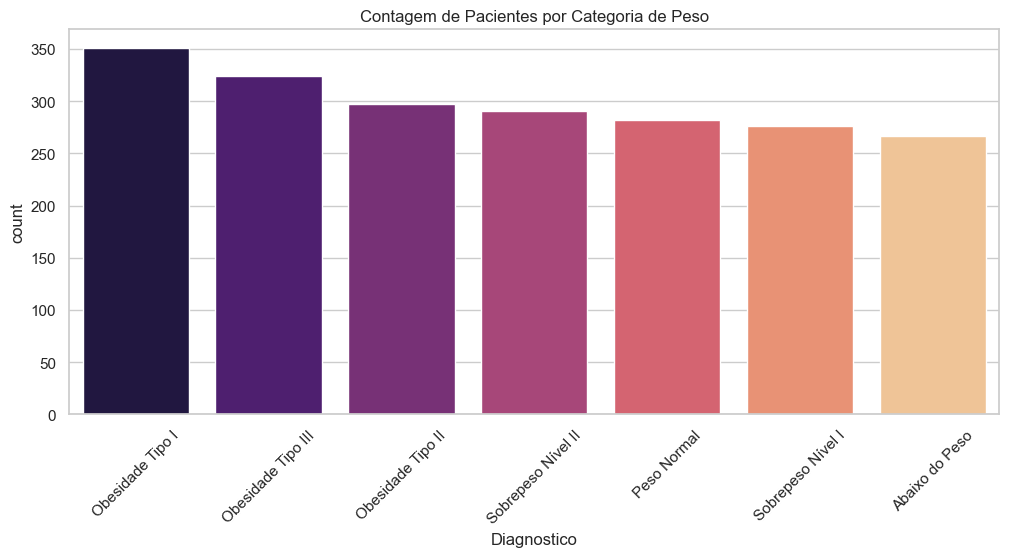

In [135]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Diagnostico', palette='magma', order=df['Diagnostico'].value_counts().index)
plt.title('Contagem de Pacientes por Categoria de Peso')
plt.xticks(rotation=45)
plt.show()

* O dataset está relativamente equilibrado

## Perfil Demográfico e Biométrico

Text(0.5, 1.0, 'Distribuição de Idade dos Pacientes')

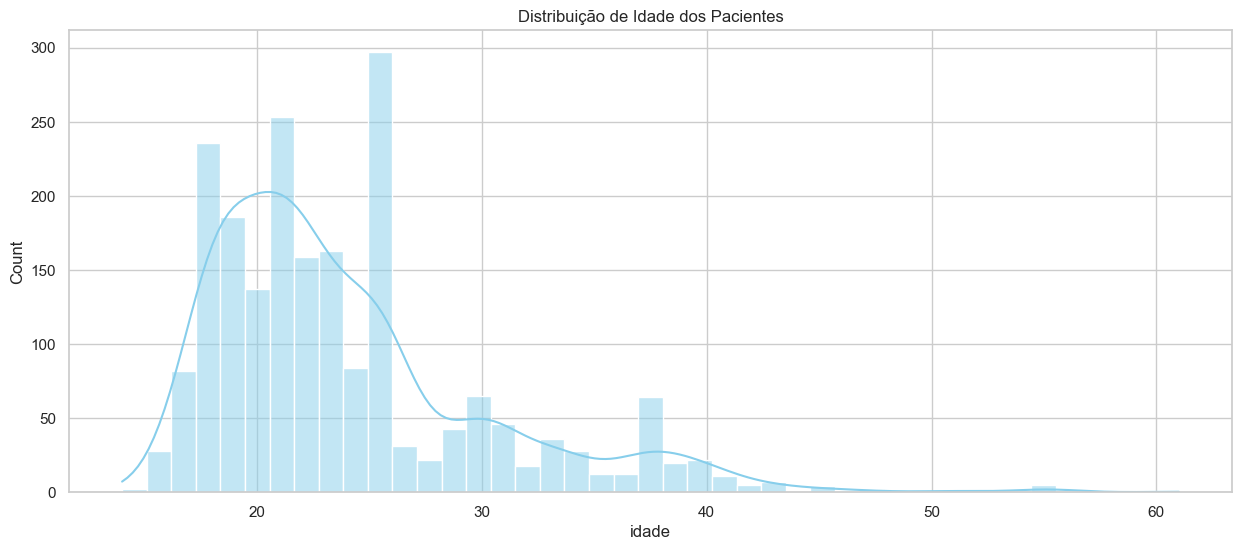

In [136]:
fig, ax = plt.subplots(figsize=(15, 6))

# Distribuição de idade
sns.histplot(df['idade'], kde=True, ax=ax, color='skyblue')
ax.set_title('Distribuição de Idade dos Pacientes')

* Público majoritariamente jovem, com um pico entre 18 e 25 anos.

C:\Users\dae2ca\AppData\Local\Temp\ipykernel_13684\3500526785.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genero', y='peso', ax=ax, palette='Set2')


Text(0.5, 1.0, 'Distribuição de Peso por Gênero')

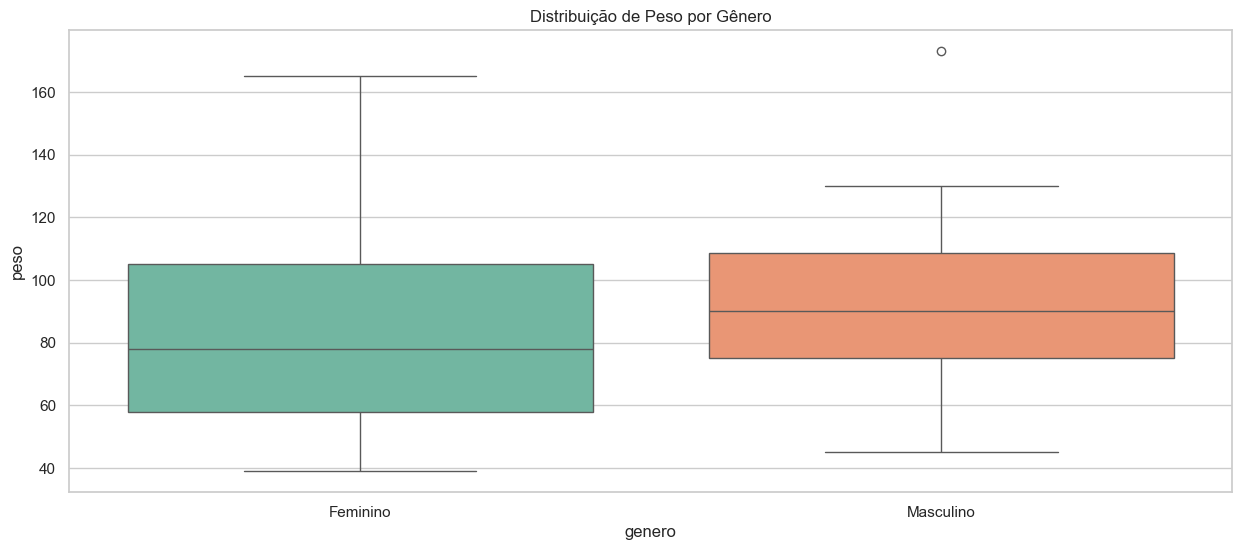

In [137]:
fig, ax = plt.subplots(figsize=(15, 6))

# Boxplot de peso por gênero
sns.boxplot(data=df, x='genero', y='peso', ax=ax, palette='Set2')
ax.set_title('Distribuição de Peso por Gênero')

* Homens tem uma mediana de peso ligeiramente superior às mulheres, mas há um outlier no grupo masculino perto dos 175kg. Precisamos garantir que o modelo lide bem com casos extremos

# Features

In [138]:
# Separando as Variáveis
X = df.drop('Diagnostico', axis=1)
y = df['Diagnostico']

In [139]:
# Dividindo em treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (1669, 16)
X_test: (418, 16)


# 4. Pipeline de Pré-Processamento

In [140]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [141]:
# Listas de categorias ordinais na ordem correta
ordem_caec_calc = ['Não consome', 'Consome às vezes', 'Consome frequentemente', 'Consome sempre']
ordem_fcvc = ['Raramente', 'Às vezes', 'Sempre']
ordem_ch2o = ['Menos de 1 litro por dia', 'De 1 a 2 litros por dia', 'Mais de 2 litros por dia']
ordem_faf  = ['Nenhuma', '1 a 2 vezes por semana', '3 a 4 vezes por semana', '5 ou mais vezes por semana']
ordem_tue  = ['0 a 2 horas por dia', '3 a 5 horas por dia', 'Mais de 5 horas por dia']
ordem_ncp = ['1 refeição', '2 refeições', '3 refeições', '4 ou mais refeições']

In [142]:
preprocessor = ColumnTransformer(
    transformers = [
        ('ord_especifico', OrdinalEncoder(categories=[
            ordem_caec_calc, ordem_caec_calc, ordem_fcvc, ordem_ch2o, ordem_faf, ordem_tue, ordem_ncp
        ]), ['CAEC', 'CALC', 'FCVC', 'CH2O', 'FAF', 'TUE', 'NCP']),

        ('bin_nom', OrdinalEncoder(), ['genero', 'historico_familiar', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']),

        ('num', StandardScaler(), ['idade', 'altura', 'peso'])
    ]
)

# Modelo Final

Escolhemos o Random Forest, que é excelente para problemas de classificação

In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [144]:
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [145]:
# Treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline_final.fit(X_train, y_train)

print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


# Avaliação de Performance

## Acurácia

In [146]:
acuracia = pipeline_final.score(X_test, y_test)
print(f'Acurácia global: {acuracia:.2%}')

Acurácia global: 96.17%


## Matriz de Confusão

In [147]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [148]:
y_pred = pipeline_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

<Figure size 1000x800 with 0 Axes>

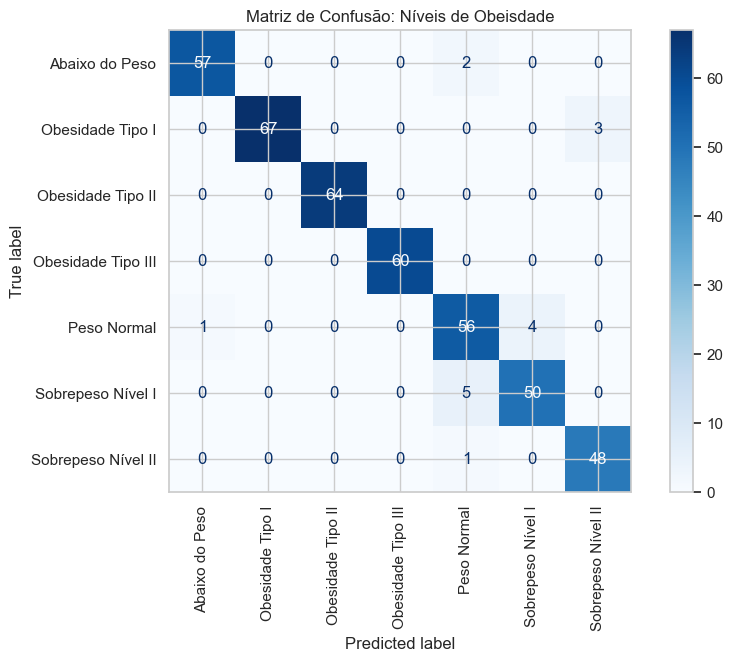

In [149]:
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Matriz de Confusão: Níveis de Obeisdade')
plt.show()

## Classification Report

In [150]:
from sklearn.metrics import classification_report

y_pred = pipeline_final.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                    precision    recall  f1-score   support

    Abaixo do Peso       0.98      0.97      0.97        59
  Obesidade Tipo I       1.00      0.96      0.98        70
 Obesidade Tipo II       1.00      1.00      1.00        64
Obesidade Tipo III       1.00      1.00      1.00        60
       Peso Normal       0.88      0.92      0.90        61
 Sobrepeso Nível I       0.93      0.91      0.92        55
Sobrepeso Nível II       0.94      0.98      0.96        49

          accuracy                           0.96       418
         macro avg       0.96      0.96      0.96       418
      weighted avg       0.96      0.96      0.96       418



# Salvando o Modelo

In [151]:
import joblib
import os

In [152]:
# Criar uma pasta chamada 'models'
if not os.path.exists('../models'):
    os.makedirs('models')

In [153]:
# Salvar o Pipeline completo (pré-processamento + modelo)
joblib.dump(pipeline_final, '../models/modelo_obesidade.pkl')

['../models/modelo_obesidade.pkl']

# Insights Acionáveis

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

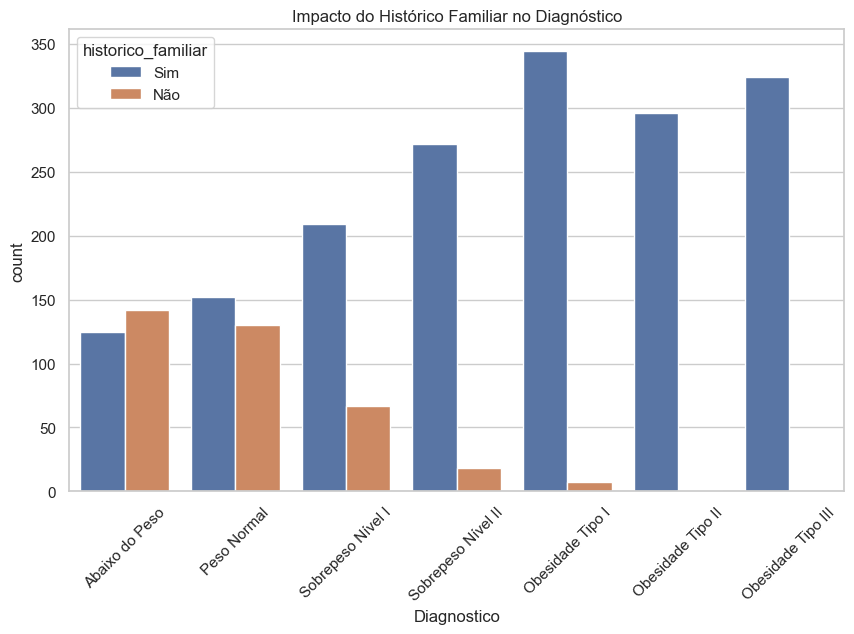

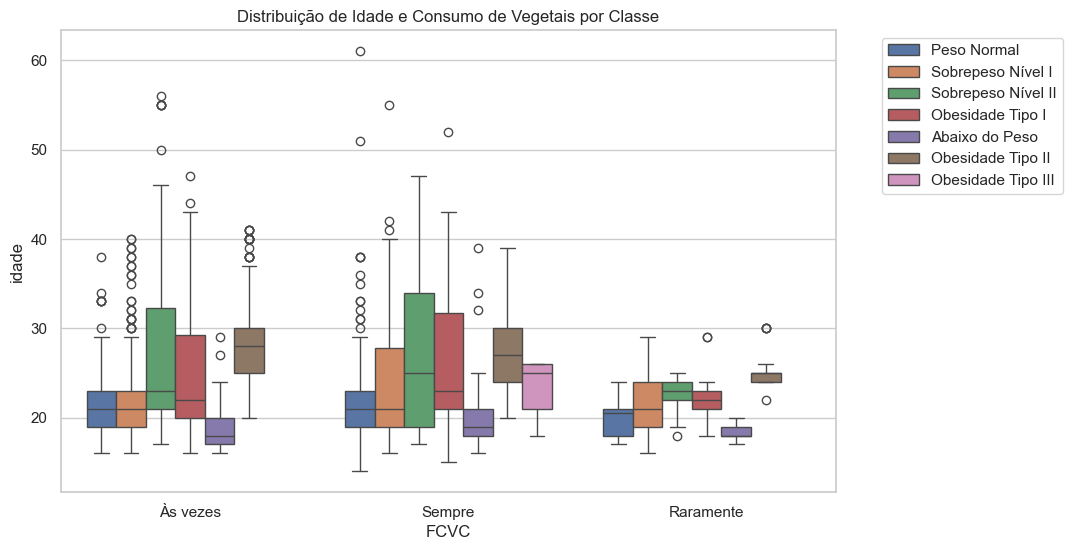

In [155]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [10,6]

# Insight 1: Histórico familiar é determinante?
plt.figure()
sns.countplot(data=df, x='Diagnostico', hue='historico_familiar',
              order=['Abaixo do Peso', 'Peso Normal', 'Sobrepeso Nível I', 
                     'Sobrepeso Nível II', 'Obesidade Tipo I', 'Obesidade Tipo II', 'Obesidade Tipo III'])
plt.xticks(rotation=45)
plt.title('Impacto do Histórico Familiar no Diagnóstico')
plt.show()

# Insight 2: Consumo de vegetais vs obesidade
plt.figure()
sns.boxplot(data=df, x='FCVC', y='idade', hue='Diagnostico')
plt.title('Distribuição de Idade e Consumo de Vegetais por Classe')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()